In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from transformers import pipeline 
import nltk
from nltk.tokenize import sent_tokenize
from time import time
import matplotlib.pyplot as plt
import torch
import re
import os, sys

c:\wamp64\www\the-simpsons-ai-analysis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Function to check if running in a virtual environment
def in_venv():
    return sys.prefix != sys.base_prefix


# Ensure NLTK resources are available. If not, download them to the appropriate location.
def ensure_nltk_resources(resources=("punkt", "punkt_tab")):
    for resource in resources:
        try:
            nltk.data.find(f"tokenizers/{resource}")
        except LookupError:
            if in_venv():
                venv_nltk_path = os.path.join(sys.prefix, "nltk_data")
                nltk.download(resource, download_dir=venv_nltk_path)
                nltk.data.path.append(venv_nltk_path)
            else:
                nltk.download(resource)

ensure_nltk_resources()

# Load Model

In [4]:
model_name = "facebook/bart-large-mnli"
device = 0 if torch.cuda.is_available() else -1 # Use GPU if available

In [5]:
device

-1

In [6]:
def load_model(device):
    """
    Load the BART model for NLI.
    """
    theme_classifier = pipeline(
        "zero-shot-classification", 
        model=model_name, 
        device=device)
    return theme_classifier

In [7]:
theme_classifier = load_model(device)

Device set to use cpu


In [8]:
theme_list = "Friendship, Stupidity, Ignorance, Family, Cult, Love, Betrayal, Revenge, Justice, Sacrifice, Courage, Loyalty, Greed, Power, Corruption, Redemption, Identity, Belonging, Freedom, Conformity, Rebellion, Hope".split(", ")

In [9]:
theme_classifier(
    "If you're going through hell, keep going.",
    candidate_labels=theme_list,
    multi_label=True
)

{'sequence': "If you're going through hell, keep going.",
 'labels': ['Courage',
  'Rebellion',
  'Power',
  'Betrayal',
  'Cult',
  'Family',
  'Identity',
  'Corruption',
  'Sacrifice',
  'Loyalty',
  'Belonging',
  'Conformity',
  'Greed',
  'Stupidity',
  'Revenge',
  'Ignorance',
  'Redemption',
  'Justice',
  'Freedom',
  'Love',
  'Hope',
  'Friendship'],
 'scores': [0.8513870239257812,
  0.3483365774154663,
  0.26827600598335266,
  0.18696649372577667,
  0.16367655992507935,
  0.13354328274726868,
  0.10696928203105927,
  0.10271888971328735,
  0.10034231096506119,
  0.04963957890868187,
  0.04932897165417671,
  0.04053553193807602,
  0.038615044206380844,
  0.037590958178043365,
  0.03523658588528633,
  0.023171957582235336,
  0.011548693291842937,
  0.004999503493309021,
  0.001713318983092904,
  0.00021350214956328273,
  0.00018351414473727345,
  0.00011580272985156626]}

# Load Dataset

In [10]:
def parse_srt(filename):
    try:
        with open(filename, 'r', encoding='utf-8') as f:
            lines = f.readlines()
    except UnicodeDecodeError:
        with open(filename, 'r', encoding='latin-1') as f:
            lines = f.readlines()

    blocks = []
    block = []
    for line in lines:
        line = line.strip()
        if line == '':
            if block:
                blocks.append(block)
                block = []
        else:
            block.append(line)
    if block:
        blocks.append(block)

    sentences = []
    for block in blocks:
        text_lines = [
            l for l in block
            if not re.match(r'^\d+$', l)
            and not re.match(r'^\d{2}:\d{2}:\d{2},\d{3}', l)
            and '♪' not in l
            and not re.search(r'<.*?>', l)  # Remove lines with HTML tags
            and not re.search(r'www\.', l, re.IGNORECASE)  # Remove lines with URLs
        ]
        text_lines = [re.sub(r'{\\an\d+}', '', l) for l in text_lines]
        if text_lines:
            sentences.append(' '.join(text_lines))
    return sentences

In [11]:
def get_season_episode_code(filename):
    # Try SxxEyy format first
    match = re.search(r'[Ss](\d{2})[Ee](\d{2})', filename)
    if match:
        return f"{match.group(1)}{match.group(2)}"
    # Try xxXyy format (e.g., 20x01)
    match = re.search(r'(\d{2})[xX](\d{2})', filename)
    if match:
        return f"{match.group(1)}{match.group(2)}"
    return None  # or handle missing code as needed

# Example usage:
files = glob("../data/subtitles/*.srt")
codes = [get_season_episode_code(os.path.basename(f)) for f in files]
codes = [c for c in codes if c is not None]
print(codes.__len__()   )

794


In [12]:
def load_subtitles_dataset(dataset_path):
    subtitles_paths = glob(dataset_path + "/*.srt")

    print(subtitles_paths)
    scripts = []
    episode_num = []

    for path in subtitles_paths:
        if not os.path.exists(path):
            print(f"File not found: {path}")
            continue
        try:
            sentences = parse_srt(path)
            if sentences:
                print(f"Loaded {len(sentences)} sentences from {path}")

                script = " ".join(sentences).strip()
                season_episode = get_season_episode_code(os.path.basename(path))

                scripts.append(script)
                episode_num.append(season_episode)
                
        
            else:
                print(f"No valid sentences found in {path}")
        except Exception as e:
            print(f"Error processing {path}: {e}")
    
    df = pd.DataFrame.from_dict({
                    "episode": episode_num,
                    "script": scripts
                })
    return df

In [13]:
dataset_path = "../data/subtitles"
df = load_subtitles_dataset(dataset_path)

['../data/subtitles\\Simpsons 20x01 Sex Pies and Idiot Scrapes.srt', '../data/subtitles\\Simpsons 20x02 Lost Verizon.srt', '../data/subtitles\\Simpsons 20x03 Double Double Boy in Trouble.srt', '../data/subtitles\\Simpsons 20x04 Treehouse of Horror XIX.srt', '../data/subtitles\\Simpsons 20x05 Dangerous Curves.srt', '../data/subtitles\\Simpsons 20x06 Homer and Lisa Exchange Cross Words.srt', '../data/subtitles\\Simpsons 20x07 Mypods and Broomsticks.srt', '../data/subtitles\\Simpsons 20x08 The Burns and the Bees.srt', '../data/subtitles\\Simpsons 20x09 Lisa the Drama Queen.srt', '../data/subtitles\\Simpsons 20x10 Take My Life Please.srt', '../data/subtitles\\Simpsons 20x11 How the Test Was Won.srt', '../data/subtitles\\Simpsons 20x12 No Loan Again Naturally.srt', '../data/subtitles\\Simpsons 20x13 Gone Maggie Gone.srt', '../data/subtitles\\Simpsons 20x14 In the Name of the Grandfather.srt', '../data/subtitles\\Simpsons 20x15 Wedding for Disaster.srt', '../data/subtitles\\Simpsons 20x16 Ee

In [14]:
df.head()

,episode,script
0,2001,The Simpsons D'oh! BART: Woo-hoo! St. Patrick'...
1,2002,"D'oh! BART: Ay, caramba! Out of gas? But how? ..."
2,2003,"D'oh! Stupid shopping list, turning food into ..."
3,2004,"Hello. I'd like to vote for president, governo..."
4,2005,D'oh! BILL: Bill and Marty here in the middle ...


# Run Model

In [15]:
script = df.iloc[0]['script']  # iloc is a way to access a row by its integer position

In [16]:
print(script)

The Simpsons D'oh! BART: Woo-hoo! St. Patrick's Day. I love how they made the river green. Actually, my nuclear plant did that. And now that you know, your life is in danger. Greetings, fellow Irishmen and lady Irishmen. I, Joseph Fitzgerald O'Malley Fitzpatrick O'Donnell... 'The Edge' Quimby, welcome you to Springfield's... ...first booze-free St. Patrick's Day! Come on, people. Your drunken shenanigans destroy this town every year. And Ireland is so much more than the imbibing of spirits. The Irish gave the world the paddy wagon, the shamrock shake, and folk dancing where you don't move your arms. Where's the IRA when you need 'em. We renounced the ways of the gun and the bomb. In the old days we would've been all over that. Oh, no. The Northern Irish are also having a parade. Two kinds of Irish people? What are they fighting over? Who gets to sleep in the bathtub? Actually, those Prots and Cathies have hated each other for centuries. It always comes down to transubstantiation... ...

In [17]:
script_sentences = sent_tokenize(script)
script_sentences[:3]

["The Simpsons D'oh!", 'BART: Woo-hoo!', "St. Patrick's Day."]

In [18]:
sentence_batch_size = 20
script_batches = []
for index in range(0, len(script_sentences), sentence_batch_size):
    sentence = " ".join(script_sentences[index:index + sentence_batch_size])
    script_batches.append(sentence)

    

In [19]:
# For inspection
script_batches[:2]

["The Simpsons D'oh! BART: Woo-hoo! St. Patrick's Day. I love how they made the river green. Actually, my nuclear plant did that. And now that you know, your life is in danger. Greetings, fellow Irishmen and lady Irishmen. I, Joseph Fitzgerald O'Malley Fitzpatrick O'Donnell... 'The Edge' Quimby, welcome you to Springfield's... ...first booze-free St. Patrick's Day! Come on, people. Your drunken shenanigans destroy this town every year. And Ireland is so much more than the imbibing of spirits. The Irish gave the world the paddy wagon, the shamrock shake, and folk dancing where you don't move your arms. Where's the IRA when you need 'em. We renounced the ways of the gun and the bomb. In the old days we would've been all over that. Oh, no. The Northern Irish are also having a parade. Two kinds of Irish people? What are they fighting over? Who gets to sleep in the bathtub?",
 "Actually, those Prots and Cathies have hated each other for centuries. It always comes down to transubstantiation.

In [20]:
theme_output = theme_classifier(
    script_batches[:2],
    theme_list,
    multi_label=True)

In [21]:
theme_output[1]

{'sequence': "Actually, those Prots and Cathies have hated each other for centuries. It always comes down to transubstantiation... ...versus consubstantiation. Stop it, both of you! You have a common land, a literature, and the sweetest songs on earth! Too-ra-Ioo-ra-Ioo-ral Too-ra-Ioo-ra-li Hush, my little baby Hush now, don't you cry ALL: Too-ra-Ioo-ra-Ioo-ral Too-ra-Ioo-ra-li Too-ra-Ioo-ra-Ioo-ral That's an Irish lullaby Oh, no! Without the booze, these guys all remember how much they hate each other! This was such a pleasant St. Patrick's Day until the Irish people showed up. Urchins! They took my cupcakes! All right, you unwanted miracles, give back the lady's cupcakes. You don't have the teeth for it. Aye, but we could gum the frosting. Well, if it's good gumming you're after, wouldn't you rather have this lovely cabbage? CHILDREN: Cabbage, cabbage! Here you go, ma'am. Not a sprinkle nor jimmy askew. Thank you so much, Mr... Patrick Farrelly at your service. Marge Simpson. Well, M

In [22]:
# Wrangle Ouput
# battle: [0.51489498, 0.2156498]
themes = {}
for output in theme_output:
    for label,score in zip(output['labels'],output['scores']):
        if label not in themes:
            themes[label] = []
        themes[label].append(score)

In [23]:
themes = {key: np.mean(np.array(value)) for key,value in themes.items()}


In [24]:
themes

{'Stupidity': np.float64(0.5273941308259964),
 'Belonging': np.float64(0.5894048511981964),
 'Betrayal': np.float64(0.43968212604522705),
 'Courage': np.float64(0.44733762741088867),
 'Justice': np.float64(0.47769297659397125),
 'Conformity': np.float64(0.30973344296216965),
 'Identity': np.float64(0.3059784695506096),
 'Family': np.float64(0.4828210175037384),
 'Freedom': np.float64(0.34893912076950073),
 'Power': np.float64(0.4170905649662018),
 'Rebellion': np.float64(0.2558273673057556),
 'Ignorance': np.float64(0.19020775333046913),
 'Loyalty': np.float64(0.3435797691345215),
 'Redemption': np.float64(0.23937033861875534),
 'Cult': np.float64(0.2203461304306984),
 'Friendship': np.float64(0.21165236085653305),
 'Sacrifice': np.float64(0.20680184662342072),
 'Greed': np.float64(0.15346752852201462),
 'Corruption': np.float64(0.15101265162229538),
 'Hope': np.float64(0.1352229304611683),
 'Revenge': np.float64(0.1540127620100975),
 'Love': np.float64(0.09723416343331337)}

In [25]:
def get_themes_inference(script):
    script_sentences = sent_tokenize(script)

    # Batch Sentence
    sentence_batch_size=20
    script_batches = []
    for index in range(0,len(script_sentences),sentence_batch_size):
        sent = " ".join(script_sentences[index:index+sentence_batch_size])
        script_batches.append(sent)
    
    # Run Model
    theme_output = theme_classifier(
        script_batches[:2],
        theme_list,
        multi_label=True
    )

    # Wrangle Output 
    themes = {}
    for output in theme_output:
        for label,score in zip(output['labels'],output['scores']):
            if label not in themes:
                themes[label] = []
            themes[label].append(score)

    themes = {key: np.mean(np.array(value)) for key,value in themes.items()}

    return themes

In [26]:
df = df.head(2)


In [27]:
df

,episode,script
0,2001,The Simpsons D'oh! BART: Woo-hoo! St. Patrick'...
1,2002,"D'oh! BART: Ay, caramba! Out of gas? But how? ..."


In [28]:
output_themes = df['script'].apply(get_themes_inference)


In [29]:
output_themes

0    {'Stupidity': 0.5273941308259964, 'Belonging':...
1    {'Stupidity': 0.8860046863555908, 'Betrayal': ...
Name: script, dtype: object

In [30]:
theme_df = pd.DataFrame(output_themes.tolist())

In [31]:
theme_df

,Stupidity,Belonging,Betrayal,Courage,Justice,Conformity,Identity,Family,Freedom,Power,...,Loyalty,Redemption,Cult,Friendship,Sacrifice,Greed,Corruption,Hope,Revenge,Love
0,0.527394,0.589405,0.439682,0.447338,0.477693,0.309733,0.305978,0.482821,0.348939,0.417091,...,0.343580,0.239370,0.220346,0.211652,0.206802,0.153468,0.151013,0.135223,0.154013,0.097234
1,0.886005,0.390437,0.556247,0.268084,0.239583,0.359945,0.265267,0.614060,0.194303,0.444208,...,0.169552,0.217601,0.173760,0.167317,0.202027,0.205058,0.247748,0.029438,0.288780,0.119791


In [32]:
df

,episode,script
0,2001,The Simpsons D'oh! BART: Woo-hoo! St. Patrick'...
1,2002,"D'oh! BART: Ay, caramba! Out of gas? But how? ..."


In [33]:
# Combine DataFrames

df[theme_df.columns] = theme_df
df

,episode,script,Stupidity,Belonging,Betrayal,Courage,Justice,Conformity,Identity,Family,...,Loyalty,Redemption,Cult,Friendship,Sacrifice,Greed,Corruption,Hope,Revenge,Love
0,2001,The Simpsons D'oh! BART: Woo-hoo! St. Patrick'...,0.527394,0.589405,0.439682,0.447338,0.477693,0.309733,0.305978,0.482821,...,0.343580,0.239370,0.220346,0.211652,0.206802,0.153468,0.151013,0.135223,0.154013,0.097234
1,2002,"D'oh! BART: Ay, caramba! Out of gas? But how? ...",0.886005,0.390437,0.556247,0.268084,0.239583,0.359945,0.265267,0.614060,...,0.169552,0.217601,0.173760,0.167317,0.202027,0.205058,0.247748,0.029438,0.288780,0.119791


# Visualize Output 

In [34]:
theme_output = df.drop(['episode','script'],axis=1).sum().reset_index()
theme_output.columns = ['theme','score']
theme_output

,theme,score
0,Stupidity,1.413399
1,Belonging,0.979842
2,Betrayal,0.995929
3,Courage,0.715421
4,Justice,0.717276
5,Conformity,0.669678
6,Identity,0.571246
7,Family,1.096881
8,Freedom,0.543243
9,Power,0.861298


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

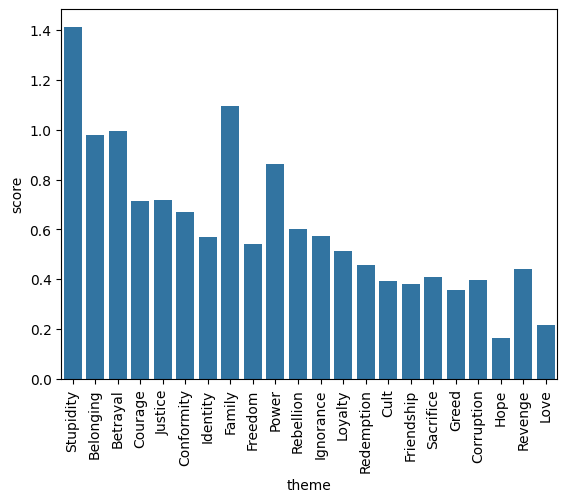

In [39]:
sns.barplot(data = theme_output ,x="theme",y="score" )
plt.xticks(rotation=90)
plt.show()